# Qicheng Sun。 82857。 Lab 9

In [ ]:
!pip install ucimlrepo scipy seaborn matplotlib

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

df_heart = pd.concat([X, y], axis=1)

In [ ]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


**Task 1.1 and 1.2**

Changing data types.

In [ ]:
df_heart.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
# print(heart_disease.metadata)
print(heart_disease.variables)

        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

In [ ]:
categorical_features = heart_disease.variables[heart_disease.variables['type'] == 'Categorical']['name'].values.tolist()

In [ ]:
categorical_features

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [ ]:
df_heart.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# new dataframe without missing values
df_heart_no_na = df_heart.dropna()

In [ ]:
# single column
# df_heart['sex'] = df_heart['sex'].astype('category')

# let's loop
for feature_name in categorical_features:
    df_heart[feature_name] = df_heart[feature_name].astype('category')
    df_heart_no_na[feature_name] = df_heart_no_na[feature_name].astype('category')

/tmp/ipykernel_2637/1199842284.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heart_no_na[feature_name] = df_heart_no_na[feature_name].astype('category')


In [ ]:
df_heart.dtypes

,0
age,int64
sex,category
cp,category
trestbps,int64
chol,int64
fbs,category
restecg,category
thalach,int64
exang,category
oldpeak,float64


**Task 2**

In [ ]:
# unique values (using subset without missing values)
df_heart_no_na['num'].unique()

array([0, 2, 1, 3, 4])

In [ ]:
df_heart_no_na['num'].value_counts()

,count
num,
0,160
1,54
2,35
3,35
4,13


**Task 2.1**

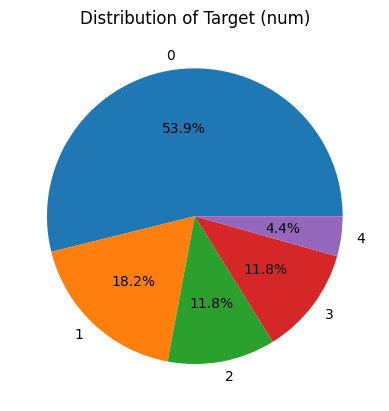

In [ ]:
import matplotlib.pyplot as plt

num_counts = df_heart_no_na['num'].value_counts()
num_counts.plot(kind='pie', autopct='%1.1f%%', ylabel='')
plt.title('Distribution of Target (num)')
plt.show()

# The data is imbalanced: class 0 dominates (~54%), while classes 3 and 4 are rare.

** Task 2.2 **

In [ ]:
numerical_features = df_heart_no_na.select_dtypes(include='number').columns.tolist()

desc_stats = df_heart_no_na[numerical_features].describe(percentiles=[0.25, 0.5, 0.75]).T
desc_stats = desc_stats.rename(columns={'50%': 'median'})
desc_stats[['min', 'max', 'mean', 'median', 'std', '25%', '75%']]

,min,max,mean,median,std,25%,75%
age,29.0,77.0,54.542088,56.0,9.049736,48.0,61.0
trestbps,94.0,200.0,131.693603,130.0,17.762806,120.0,140.0
chol,126.0,564.0,247.350168,243.0,51.997583,211.0,276.0
thalach,71.0,202.0,149.599327,153.0,22.941562,133.0,166.0
oldpeak,0.0,6.2,1.055556,0.8,1.166123,0.0,1.6
ca,0.0,3.0,0.676768,0.0,0.938965,0.0,1.0
num,0.0,4.0,0.946128,0.0,1.234551,0.0,2.0


**Task 2.3**

In [ ]:
modes = {feature: df_heart_no_na[feature].mode()[0] for feature in categorical_features}
pd.Series(modes, name='mode')

,mode
sex,1.0
cp,4.0
fbs,0.0
restecg,0.0
exang,0.0
slope,1.0
thal,3.0


**Task 2.4**

In [ ]:
import seaborn as sns

corr_matrix = df_heart_no_na[numerical_features].corr()
corr_matrix

,age,trestbps,chol,thalach,oldpeak,ca,num
age,1.000000,0.290476,0.202644,-0.394563,0.197123,0.362210,0.222156
trestbps,0.290476,1.000000,0.131536,-0.049108,0.191243,0.097954,0.159620
chol,0.202644,0.131536,1.000000,-0.000075,0.038596,0.115945,0.066448
thalach,-0.394563,-0.049108,-0.000075,1.000000,-0.347640,-0.268727,-0.420639
oldpeak,0.197123,0.191243,0.038596,-0.347640,1.000000,0.294452,0.501461
ca,0.362210,0.097954,0.115945,-0.268727,0.294452,1.000000,0.521178
num,0.222156,0.159620,0.066448,-0.420639,0.501461,0.521178,1.000000


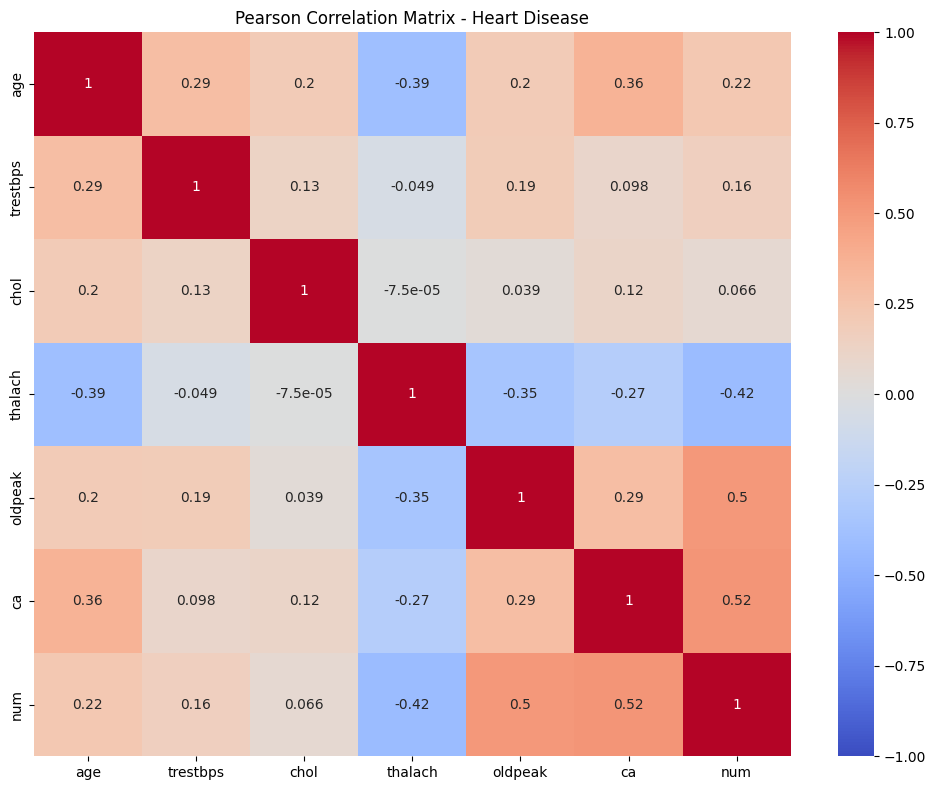

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix - Heart Disease')
plt.tight_layout()
plt.show()

**Task 2.5**

In [ ]:
top3_age_corr = (
    corr_matrix['age']
    .drop('age')
    .abs()
    .sort_values(ascending=False)
    .head(3)
)
top3_age_corr

,age
thalach,0.394563
ca,0.362210
trestbps,0.290476


**Task 3**

Load the Adult dataset and set categorical types.

In [ ]:
adult = fetch_ucirepo(id=2)

df_adult = pd.concat([adult.data.features, adult.data.targets], axis=1)
df_adult = df_adult.replace('?', pd.NA).dropna()

categorical_adult = adult.variables[adult.variables['type'] == 'Categorical']['name'].values.tolist()
for feature_name in categorical_adult + ['sex', 'income']:
    df_adult[feature_name] = df_adult[feature_name].astype('category')

df_adult.dtypes

,0
age,int64
workclass,category
fnlwgt,int64
education,category
education-num,int64
marital-status,category
occupation,category
relationship,category
race,category
sex,category


**Task 3.1**

Two-sample t-test (independent samples) for `capital-gain` comparing `race='White'` vs all other races.

Null hypothesis: the mean `capital-gain` for White respondents is significantly higher than for other races.

In [ ]:
from scipy import stats

white_capital_gain = df_adult.loc[df_adult['race'] == 'White', 'capital-gain'].astype(float)
other_capital_gain = df_adult.loc[df_adult['race'] != 'White', 'capital-gain'].astype(float)

t_stat, p_value = stats.ttest_ind(white_capital_gain, other_capital_gain, alternative='greater', equal_var=False)

print(f'White mean: {white_capital_gain.mean():.2f}')
print(f'Other races mean: {other_capital_gain.mean():.2f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print('Accept H0: White respondents have a significantly higher mean capital-gain.')
else:
    print('Reject H0: no significant evidence that White mean capital-gain is higher.')

White mean: 1151.72
Other races mean: 791.79
t-statistic: 4.0395
p-value: 0.000027
Accept H0: White respondents have a significantly higher mean capital-gain.


**Task 3.2**

One-way ANOVA for `capital-gain` across all `race` categories.

In [ ]:
race_groups = [
    group['capital-gain'].astype(float)
    for _, group in df_adult.groupby('race', observed=True)
]

f_stat, p_value_anova = stats.f_oneway(*race_groups)

print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_value_anova:.6f}')

if p_value_anova < alpha:
    print('Interpretation: at least one race group has a significantly different mean capital-gain.')
else:
    print('Interpretation: no statistically significant difference in mean capital-gain across race groups.')

F-statistic: 6.2920
p-value: 0.000047
Interpretation: at least one race group has a significantly different mean capital-gain.


**Task 4**

Chi-square test for the `income` feature between two age groups:
* people aged < 40
* people aged >= 40

(The exercise text refers to `capital-income`; the Adult dataset provides the categorical `income` column, which is used here.)

In [ ]:
df_adult['age_group'] = pd.cut(
    df_adult['age'].astype(float),
    bins=[0, 40, 120],
    labels=['<40', '>=40'],
    right=False
)

contingency_table = pd.crosstab(df_adult['age_group'], df_adult['income'])
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print('Contingency table:')
display(contingency_table)
print(f'Chi-square statistic: {chi2_stat:.4f}')
print(f'p-value: {p_value_chi2:.6f}')
print(f'degrees of freedom: {dof}')

if p_value_chi2 < alpha:
    print('Interpretation: income distribution differs significantly between the two age groups.')
else:
    print('Interpretation: no significant association between age group and income.')

Contingency table:


income,<=50K,<=50K.,>50K,>50K.
age_group,,,,
<40,14259,7061,2736,1351
>=40,8395,4299,4772,2349


Chi-square statistic: 2355.2690
p-value: 0.000000
degrees of freedom: 3
Interpretation: income distribution differs significantly between the two age groups.
